#### This code is for running the ECMWF S2S Forecast data within the ellipse calculation code.

At the end is a sample timeseries plot of these calculated elliptical metrics. 

In [1]:
##imports for relevant packages 

import datetime as dt
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import cartopy.feature
from cartopy.util import add_cyclic_point
import cartopy.crs as ccrs
import xarray as xr
import math
import netCDF4
#from get_ellipse_metrics import get_emetrics_max_min
from fitEllipse2_new import fitEllipseContour
#from EllipseCalc import ellipse_calc
from geopy.distance import great_circle
from matplotlib.patches import Polygon
from matplotlib import cm #colormaps!
import copy
import os
import scipy.stats
import pickle
import matplotlib.ticker as mticker

In [2]:
#### Define functions first:
def point_inside_polygon(x,y,xarr,yarr):

	n = len(xarr)
	inside =False

	p1x = xarr[0]
	p1y = yarr[0]
	for i in range(n+1):
		p2x,p2y = xarr[i % n],yarr[i % n]
		if y > min(p1y,p2y):
			if y <= max(p1y,p2y):
				if x <= max(p1x,p2x):
					if p1y != p2y:
						xinters = (y-p1y)*(p2x-p1x)/(p2y-p1y)+p1x
					if p1x == p2x or x <= xinters:
						inside = not inside
		p1x,p1y = p2x,p2y

	return inside;

In [3]:
lev_list = [10,50] #Define your list of hPa levels
#contour_list = [31500,20000,23000]
contour_list = [30000,20000] #Define your list of contours relevant to hPa measures
windlat = 60.0 #Define latitude for zonal-mean winds
write_out = True #write the ellipse data to a text file, True or False 

In [4]:
##create arrays for the elliptical metrics 
rat10 = np.empty((12,47))
wind10 = np.empty((12,47))
cenlat10 = np.empty((12,47))
cenlon10 = np.empty((12,47))
size10 = np.empty((12,47))
ep10 = np.empty((12,47))
num10 = np.empty((12,47))
  
rat50 = np.empty((12,47))
wind50 = np.empty((12,47))
cenlat50 = np.empty((12,47))
cenlon50 = np.empty((12,47))
size50 = np.empty((12,47))
ep50 = np.empty((12,47))
num50 = np.empty((12,47))

In [5]:
#Start with defining desired period of record
year = 2018
month = 12
day = 26
date1 = dt.datetime(year,month,day,0)  #first date to plot
total_days = 47
first_fhr = 0
hours = total_days * 24
hr_inc = 24
times = [date1 + dt.timedelta(hours=x) for x in range(0,hours,hr_inc)]
date_list = netCDF4.date2num(times,units="hours since 1800-01-01 00:00:00",calendar="gregorian") #change dates to netcdf times

In [6]:
gfile = xr.open_dataset("../../../Prospectus/S2SData/ECMWF_gh_20191226.nc")
g_files = gfile["gh"]

g_files

<xarray.DataArray 'gh' (time: 940, number: 10, level: 10, latitude: 121, longitude: 240)>
[2729760000 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float32 0.0 1.5 3.0 4.5 ... 354.0 355.5 357.0 358.5
  * latitude   (latitude) float32 90.0 88.5 87.0 85.5 ... -87.0 -88.5 -90.0
  * level      (level) int32 10 50 100 200 300 500 700 850 925 1000
  * number     (number) int32 1 2 3 4 5 6 7 8 9 10
  * time       (time) datetime64[ns] 1999-12-26 1999-12-27 ... 2019-02-10
Attributes:
    units:          gpm
    long_name:      Geopotential Height
    standard_name:  geopotential_height

In [10]:
for plot_lev,the_contour in zip(lev_list,contour_list): #loop through each level
    print("Opening ECMWF data "+str(plot_lev)+" and contour level "+str(the_contour))
    ens_mem = [1,2,3,4,5,6,7,8,9,10] #indicate ensemble members
    text_file2 = "./"+date1.strftime("%Y%m%d_%H%M")+"_temp"+str(plot_lev)+".txt"
    fout2 = open(text_file2,'w')
    
    if plot_lev == 10:
        gfile = xr.open_dataset("../../../Prospectus/S2SData/ECMWF_gh_20191226.nc")
        g_files = gfile["gh"]
        tfile = xr.open_dataset("../../../Prospectus/S2SData/ECMWF_t_20191226.nc")
        t_files = tfile["t"]
        ufile = xr.open_dataset("../../../Prospectus/S2SData/ECMWF_u_20191226.nc")
        u_files = ufile["u"]
        
        print("Partitioning and averaging data.")
        print("First, g data")
        g_data = g_files.loc[dict(latitude=slice(90,0),level=lev_list,number=ens_mem)]
        print("u data")
        u_data = u_files.loc[dict(latitude=slice(windlat+1,windlat-1),level=lev_list,number=ens_mem)].mean(dim='longitude')
        print("t data")
        t_data = t_files.loc[dict(latitude=slice(90,75),level=lev_list,number=ens_mem)]
        tlats = t_data['latitude'].values
        weights=np.cos(np.deg2rad(t_data.latitude))
        weights.name = "weights"
        
        print("lat and lon")
        lats_era = g_data["latitude"].values
        lons_era = g_data["longitude"].values
    
    print(f"level: {plot_lev}")
    for mm in range(len(ens_mem)):
        member = ens_mem[mm]
        print("AHHHHHH "+str(mm))
        rat = []
        cenlt = []
        cenln = []
        wind = []
        sz = []
        ep = []
        number = []
        
        for date in date_list: #loop through each day 
            print(f"date: {date_list}")
            ind = np.where(date_list == date)[0]
            for d in ind:
                t = d
                height = g_data.loc[dict(time=times[t],level=plot_lev,number=member)]
                u = u_data.loc[dict(time=times[t],level=plot_lev,number=member)].mean(dim='latitude')
                tdata = t_data.loc[dict(time=times[t],level=plot_lev,number=member)].mean(dim='longitude')   
                #tdata2 = t2_data.loc[dict(time=times[t])]
            temp = tdata.weighted(weights).mean(dim='latitude')
            
            print("t2data")
            formatted_date = times[t].strftime("%Y%m%d")
            emark = []
            eline = []
            cs_temp = []
            print("##########################")
            print(date)
            print("Date "+times[t].strftime("%H UTC %d %b %Y"))
            valid_label = (times[t].strftime("Valid: %H UTC %d %b %Y"))
            
            plt.Figure(figsize=(15,15),dpi=120)#figure(figsize=(12,12),dpi=1200) <---Set fig size here!
            #ax = plt.subplot(1,1,1,projection=ccrs.Orthographic(0,90))
            ax = plt.axes(projection=ccrs.Orthographic(0,90))
            ax.add_feature(cartopy.feature.LAND, zorder=1, edgecolor='dimgray',facecolor='none')
            #ax.set_extent([-180,180,0,90],ccrs.PlateCarree())
            ax.outline_patch.set_edgecolor('none')
            gl = ax.gridlines(color="grey",linestyle=":",linewidth=0.5)#=lat_lon_width)
            
            clevs = range(18000,33500,250)
            [x,y] = np.meshgrid(lons_era,lats_era)
            #[x2,y2] = np.meshgrid(tlons_era,tlats_era)
            
            plt.title(str(plot_lev)+"hPa Elliptical Diagnostics\n"+valid_label)
            mem_color = "blue"
            mem_lw = 3.0
            mem_ms = 8
            cont_color = "#aec2e2"
            cont_lw = 1.0
            cs_temp.append(ax.contour(x,y,height,levels=clevs,linewidths=cont_lw,colors=cont_color))
            
            line_w = np.array(clevs,dtype=np.float)
            for i,c in enumerate(clevs):
                if c == the_contour:
                    line_w[i] = 1.5 # Make the contour we're using for the ellipse calc fatter
                else:
                    line_w[i] = 0.5
            print(clevs)
            
            ax.contour(x,y,height,clevs,transform=ccrs.PlateCarree(),extend='both',colors='black',linewidths=line_w)
            #ax.contour(x2,y2,tdata2, lev = [tmean], transform=ccrs.PlateCarree(),extend='both',colors='blue',linewidths=line_w)
            
            try:
                lev_contour_ind = np.where(np.array(cs_temp[-1].levels)==the_contour)[0][0]
                isoline_list = cs_temp[-1].allsegs[lev_contour_ind]
                print("in try")
                print("Number of ellipses: ",len(isoline_list))
            except:
                print("Contours not found for",the_contour,"meter level at",plot_lev,"hPa.")
                isoline_list = []
            
            if len(isoline_list) > 0:
                lev_contour_ind = np.where(np.array(cs_temp[-1].levels)==the_contour)[0][0]
                isoline_list = cs_temp[-1].allsegs[lev_contour_ind]
                #print(isoline_list)
                print("in elipse ...")
                print("Number of ellipses: ",len(isoline_list))
            else:
                print("Contours not found for",the_contour,"meter level at",plot_lev,"hPa.")
                isoline_list = []
            
            ##number of contours
            isocount = 0
            small = 0
            #empty lists for upcoming metric calculations
            ratio1 = []
            uvalues1 = []
            cenlat1 = []
            cenlon1 = []
            size1 = []
            ephi1 = []
            
            for isoline in isoline_list:
                ##next few lines will check if the contour crossing the prime meridian is one continuous contour or two separate ones
                #print('isoline',isoline)
                #[iso_lon,iso_lat] = mm(isoline[:,0],isoline[:,1],inverse=True)
                [iso_lon,iso_lat] = [isoline[:,0],isoline[:,1]]
                if len(iso_lon)<15:
                    #print("-----Not analyzing ellipse with",len(iso_lon),"points, continuing...")  # Check for size!
                    small = 1
                    continue
                # Checking to see if contours are closed (0) or need to be joined (1)  Checking before convert lat/lon to radians
                lon_diff = abs(iso_lon[0] - iso_lon[len(iso_lon)-1])
                lat_diff = abs(iso_lat[0] - iso_lat[len(iso_lat)-1])
                join = 0
                if lon_diff > 1 or lat_diff > 1:
                    join = 1
                    #print("Diffs lat/lon: ",lat_diff,lon_diff)
                iso_lon = np.deg2rad(iso_lon)
                iso_lat = np.deg2rad(iso_lat)
                
                ex = np.array((np.cos(iso_lon)*np.cos(iso_lat))/(1+np.sin(iso_lat)))
                ey = np.array((np.sin(iso_lon)*np.cos(iso_lat))/(1+np.sin(iso_lat)))
                ## does this contour include the pole?
                overpole = point_inside_polygon(0,0,ex,ey)  #returns true if poly includes the pole, false if not 
                #print("It is",overpole, "that the contour includes the pole")
                if not overpole and len(isoline_list) > 1 and join > 0 and small < 1:
                    if isocount > 0:
                        ex = np.append(ex,ex2)
                        ey = np.append(ey,ey2)
                        #print("Point didn't include pole - add to these to previous set")
                    else:
                        ex2 = ex
                        ey2 = ey
                        #print("Point didn't include pole - keeping these to add to next set")
                        isocount = 1
                        continue
                ##begin actual calculation        
                #print("Running ellipse diagnostic now")
                exx,eyy,eaax,ebax,ecenterx,ecentery,ephi = fitEllipseContour(ex,ey)
                
                ## Convert back to lat/lon
                elons = np.where(exx<0,np.where(eyy>0,np.arctan(eyy/exx)+math.pi,np.arctan(eyy/exx)-math.pi),np.arctan(eyy/exx))
                yysinxxlon = eyy/np.sin(elons)
                elats = -2*(np.arctan(yysinxxlon) - (math.pi/4.0))
                elats = np.rad2deg(elats)
                elons = np.rad2deg(elons)
                
                ## Still not really sure what this is for...
                for g in range(1,len(elats)):
                    if abs(elats[g]-elats[g-1]) > 1.5:
                        elats[g] = elats[g-1]
                
                ## Center points back to lat/lon
                cenlon = np.where(ecenterx<0,np.where(ecentery>0,np.arctan(ecentery/ecenterx)+math.pi,np.arctan(ecentery/ecenterx)-math.pi),np.arctan(ecentery/ecenterx))
                ysinlon = ecentery/np.sin(cenlon)
                cenlat = np.rad2deg(-2 * (np.arctan(ysinlon) - (math.pi/4.0)))
                cenlon = np.rad2deg(cenlon)
                #print("Center of ellipse:",cenlat,"N",cenlon,"E")
                
                ## Calculate endpoints of the axes of the vortex, convert to lat/lon
                xa = eaax * np.cos(ephi)
                ya = eaax * np.sin(ephi)
                xb = ebax * np.sin(ephi)
                yb = ebax * np.cos(ephi)
                endx = np.array([ecenterx+xa,ecenterx-xa,ecenterx+xb,ecenterx-xb])
                endy = np.array([ecentery+ya,ecentery-ya,ecentery-yb,ecentery+yb])
                endlon = np.where(endx < 0,np.where(endy>0,np.arctan(endy/endx)+math.pi,np.arctan(endy/endx)-math.pi),np.arctan(endy/endx))
                ysinelon = endy/np.sin(endlon)
                endlat = np.rad2deg(-2 *(np.arctan(ysinelon) - (math.pi/4)))
                endlon = np.rad2deg(endlon)
                
                ## Calc great circle distances; (still necessary?) 
                a1gc = great_circle((endlat[0],endlon[0]),(cenlat,cenlon)).km
                a2gc = great_circle((cenlat,cenlon),(cenlat,endlat[1])).km
                b1gc = great_circle((endlat[2],endlon[2]),(cenlat,cenlon)).km
                b2gc = great_circle((cenlat,cenlon),(endlat[3],endlon[3])).km
                
                ephi = np.rad2deg(ephi)
                if a1gc < b1gc:
                    ephi -= 90
                    #print("Emetrics phi:",ephi)
                if ephi < -45:
                    ephi += 180
                ratio = a1gc/b1gc
                if ratio < 1.0:
                    ratio = 1.0/ratio
                size = math.pi*a1gc*b1gc
                estr = times[t].strftime("%H %Y%m%d%H")+" "+f'{cenlon:.3f}'+" "+f'{cenlat:.3f}'+" "+f'{a1gc:.3f}'+" "+f'{b1gc:.3f}'+" "+f'{ephi:.3f}'+" "+f'{u.values:.3f}'+" "+f'{temp.values:.3f}'
                
                exy=np.array(list(zip(elons,elats)))
                plt.plot(elons,elats,color='red',transform=ccrs.Geodetic(),linewidth=mem_lw)
                plt.plot(cenlon,cenlat,markersize=4,marker='o',color='red',transform=ccrs.PlateCarree())
                #ax.add_patch(Polygon(exy,closed=True,color='magenta',fill=False,lw=mem_lw,transform=ccrs.PlateCarree()))

                ##append values to the empty lists for this day/iteration
                ratio1.append(ratio)
                uvalues1.append(u.values)
                cenlat1.append(cenlat)
                cenlon1.append(cenlon)
                size1.append(size)
                ephi1.append(ephi)

            #check how many vortices and average is >= 1 and inout nan if 0
            if len(ratio1) >= 1:
                rat.append(np.mean(ratio1))
                wind.append(np.mean(uvalues1))
                cenlt.append(np.median(cenlat1))
                cenln.append(np.median(cenlon1))
                sz.append(np.mean(size1))
                ep.append(np.mean(ephi1))
                number.append(len(ratio1))
            
            if len(ratio1) == 0:
                rat.append(np.nan)
                wind.append(np.nan)
                cenlt.append(np.nan)
                cenln.append(np.nan)
                sz.append(np.nan)
                ep.append(np.nan)
                number.append(0)
        
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`")
        print("Ensemble #: "+str(mm))
        print(len(rat))
        print(rat)
        if plot_lev == 10:
            print('lev 10')
            rat10[mm]= rat[:]
            wind10[mm]= wind[:]
            cenlat10[mm]= cenlt[:]
            cenlon10[mm]= cenln[:]
            size10[mm]= sz[:]
            ep10[mm]= ep[:]
            num10[mm]= number[:]
        
        if plot_lev == 50:
            print('lev 50')
            rat50[mm]= rat[:]
            wind50[mm]= wind[:]
            cenlat50[mm]= cenlt[:]
            cenlon50[mm]= cenln[:]
            size50[mm]= sz[:]
            ep50[mm]= ep[:]
            num50[mm]= number[:]


Opening ECMWF data 10 and contour level 30000
Partitioning and averaging data.
First, g data
u data
t data
lat and lon
level: 10
AHHHHHH 0
date: [1919568 1919592 1919616 1919640 1919664 1919688 1919712 1919736 1919760
 1919784 1919808 1919832 1919856 1919880 1919904 1919928 1919952 1919976
 1920000 1920024 1920048 1920072 1920096 1920120 1920144 1920168 1920192
 1920216 1920240 1920264 1920288 1920312 1920336 1920360 1920384 1920408
 1920432 1920456 1920480 1920504 1920528 1920552 1920576 1920600 1920624
 1920648 1920672]
t2data
##########################
1919568
Date 00 UTC 26 Dec 2018


/tmp/ipykernel_1752758/2523770888.py:68: DeprecationWarning: The outline_patch property is deprecated. Use GeoAxes.spines['geo'] or the default Axes properties instead.
  ax.outline_patch.set_edgecolor('none')


range(18000, 33500, 250)
in try
Number of ellipses:  1
in elipse ...
Number of ellipses:  1
old center = [0.17156261 0.0293617 ]
old angle of rotation = 41.29674494583288
old axes = [0.28736514 0.17547343]
center = [0.17156261 0.0293617 ]
angle of rotation = 41.29674494583288
axes = [0.28736514 0.17547343]
0.28736513959951726 0.1754734276008962 0.17156261323236388 0.029361703539001985 0.720764169661111
date: [1919568 1919592 1919616 1919640 1919664 1919688 1919712 1919736 1919760
 1919784 1919808 1919832 1919856 1919880 1919904 1919928 1919952 1919976
 1920000 1920024 1920048 1920072 1920096 1920120 1920144 1920168 1920192
 1920216 1920240 1920264 1920288 1920312 1920336 1920360 1920384 1920408
 1920432 1920456 1920480 1920504 1920528 1920552 1920576 1920600 1920624
 1920648 1920672]
t2data
##########################
1919592
Date 00 UTC 27 Dec 2018


/tmp/ipykernel_1752758/2523770888.py:68: DeprecationWarning: The outline_patch property is deprecated. Use GeoAxes.spines['geo'] or the default Axes properties instead.
  ax.outline_patch.set_edgecolor('none')


range(18000, 33500, 250)
in try
Number of ellipses:  1
in elipse ...
Number of ellipses:  1
old center = [0.15191308 0.00201842]
old angle of rotation = -39.66158836363252
old axes = [0.15688215 0.3040722 ]
center = [0.15191308 0.00201842]
angle of rotation = -39.66158836363252
axes = [0.15688215 0.3040722 ]
0.1568821531672693 0.3040721987924855 0.1519130785953744 0.0020184230893225963 -0.6922253035160575
date: [1919568 1919592 1919616 1919640 1919664 1919688 1919712 1919736 1919760
 1919784 1919808 1919832 1919856 1919880 1919904 1919928 1919952 1919976
 1920000 1920024 1920048 1920072 1920096 1920120 1920144 1920168 1920192
 1920216 1920240 1920264 1920288 1920312 1920336 1920360 1920384 1920408
 1920432 1920456 1920480 1920504 1920528 1920552 1920576 1920600 1920624
 1920648 1920672]
t2data
##########################
1919616
Date 00 UTC 28 Dec 2018


...

in try
Number of ellipses:  1
in elipse ...
Number of ellipses:  1
old center = [0.20952686 0.0159123 ]
old angle of rotation = 12.030435885555026
old axes = [0.23160814 0.19477383]
center = [0.20952686 0.0159123 ]
angle of rotation = 12.030435885555026
axes = [0.23160814 0.19477383]
0.23160813764079444 0.1947738282926493 0.20952685719631575 0.015912295684196692 0.2099707166530149
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
Ensemble #: 5
47
[1.5773877007676882, 1.9817117185198634, 2.346990781435946, 2.873762615650451, 3.0972463898243534, 2.5517754403185102, 1.8872626343337773, 1.511473090777576, 1.4595076747478959, 1.384961019159661, nan, 1.3863387425934905, 1.3957431059063983, 1.4783691177862501, 1.5018309843819533, 1.2710839782353474, 1.2549048084607624, 1.4188639317962812, 1.4381844157646475, 1.3822012877897287, 1.3556270501859913, 1.3595728197320698, 1.3670542504520529, 1.282582576911695, 1.0954407659628553, 1.0121137069688295, 1.1544526571415696, 1.226343327795941, 1.26511257

/tmp/ipykernel_1752758/2523770888.py:68: DeprecationWarning: The outline_patch property is deprecated. Use GeoAxes.spines['geo'] or the default Axes properties instead.
  ax.outline_patch.set_edgecolor('none')


range(18000, 33500, 250)
in try
Number of ellipses:  1
in elipse ...
Number of ellipses:  1
old center = [0.17136018 0.02926252]
old angle of rotation = 41.15146996443332
old axes = [0.28688906 0.17517721]
center = [0.17136018 0.02926252]
angle of rotation = 41.15146996443332
axes = [0.28688906 0.17517721]
0.2868890649469178 0.17517721069110223 0.1713601824134898 0.029262521262071114 0.7182286429149152
date: [1919568 1919592 1919616 1919640 1919664 1919688 1919712 1919736 1919760
 1919784 1919808 1919832 1919856 1919880 1919904 1919928 1919952 1919976
 1920000 1920024 1920048 1920072 1920096 1920120 1920144 1920168 1920192
 1920216 1920240 1920264 1920288 1920312 1920336 1920360 1920384 1920408
 1920432 1920456 1920480 1920504 1920528 1920552 1920576 1920600 1920624
 1920648 1920672]
t2data
##########################
1919592
Date 00 UTC 27 Dec 2018


/tmp/ipykernel_1752758/2523770888.py:68: DeprecationWarning: The outline_patch property is deprecated. Use GeoAxes.spines['geo'] or the default Axes properties instead.
  ax.outline_patch.set_edgecolor('none')


KeyboardInterrupt: 

Download relevant temperature data. 

In [8]:
tdata = t_data.loc[dict(level=10,latitude=slice(90,20),longitude=slice(290,320))]  
tdat = tdata.mean(dim="longitude")
td = tdat.mean(dim="latitude")
td

<xarray.DataArray 't' (time: 940, number: 10)>
array([[196.02304, 196.13702, 195.95024, ..., 196.12729, 196.3186 ,
        195.84377],
       [195.85358, 196.00684, 196.07857, ..., 196.0229 , 196.10052,
        195.65245],
       [192.22325, 192.20912, 192.23466, ..., 192.33179, 192.19379,
        192.17363],
       ...,
       [195.90128, 198.67702, 195.76723, ..., 200.24681, 203.81422,
        194.61583],
       [196.76382, 198.28114, 196.26231, ..., 200.86674, 203.91693,
        193.99391],
       [197.736  , 198.54794, 196.24414, ..., 201.37975, 202.21999,
        192.89018]], dtype=float32)
Coordinates:
    level    int32 10
  * number   (number) int32 1 2 3 4 5 6 7 8 9 10
  * time     (time) datetime64[ns] 1999-12-26 1999-12-27 ... 2019-02-10

In [17]:
#calculate ensemble mean
ens_rat10 = np.nanmean(rat10[:10], axis=0)
ens_wind10 = np.nanmean(wind10[:10], axis=0)
ens_cenlat10 = np.nanmean(cenlat10[:10], axis=0)
ens_cenlon10 = np.nanmean(cenlon10[:10], axis=0)
ens_size10 = np.nanmean(size10[:10], axis=0)
ens_ep10 = np.nanmean(ep10[:10], axis=0)
ens_num10 = np.nanmean(num10[:10], axis=0)

In [18]:
for x in range(len(ens_rat10)):
    if ens_rat10[x] <= -10:
       ens_rat10[x] = 0 
    elif ens_rat10[x] >= 10:
       ens_rat10[x] = 0 

In [19]:
##pick 2019
rat10[10,:] = ens_rat10
wind10[10,:] = ens_wind10
cenlat10[10,:] = ens_cenlat10
cenlon10[10,:] = ens_cenlon10
size10[10,:] = ens_size10
ep10[10,:] = ens_ep10
num10[10,:] = ens_num10

Set list of forecast hour times. 

In [20]:
forecast_days = [i for i in range(0,47,1)]

In [21]:
infile = open("../CompAnalysis/diagnostics/wind_1959.p", 'rb') 
wind = pickle.load(infile)
infile.close()

infile = open("../CompAnalysis/diagnostics/size_1959.p", 'rb') 
size = pickle.load(infile)
infile.close()

infile = open("../CompAnalysis/diagnostics/ratio_1959.p", 'rb') 
rat = pickle.load(infile)
infile.close()

infile = open("../CompAnalysis/diagnostics/ephi_1959.p", 'rb') 
ephi = pickle.load(infile)
infile.close()

infile = open("../CompAnalysis/diagnostics/cenlat_1959.p", 'rb')
cenlat = pickle.load(infile)
infile.close()

infile = open("../CompAnalysis/diagnostics/cenlon_1959.p", 'rb') 
cenlon = pickle.load(infile)
infile.close()

infile = open("../CompAnalysis/diagnostics/number_1959.p", 'rb') 
number = pickle.load(infile)
infile.close()

In [22]:
number.shape

(64, 151)

In [23]:
#remove repeat year
wind = np.delete(wind,[20],0)
rat = np.delete(rat,[20],0)
cenlat = np.delete(cenlat,[20],0)
cenlon = np.delete(cenlon,[20],0)
size = np.delete(size,[20],0)
ephi = np.delete(ephi,[20],0)
num = np.delete(number,[20],0)

In [24]:
wind.shape

(63, 2, 151)

In [25]:
wind = np.nanmean(wind,axis=1)
rat = np.nanmean(rat,axis=1)
cenlat = np.nanmean(cenlat,axis=1)
cenlon = np.nanmean(cenlon,axis=1)
size = np.nanmean(size,axis=1)
ephi = np.nanmean(ephi,axis=1)

/tmp/ipykernel_1752758/3908712046.py:1: RuntimeWarning: Mean of empty slice
  wind = np.nanmean(wind,axis=1)
/tmp/ipykernel_1752758/3908712046.py:2: RuntimeWarning: Mean of empty slice
  rat = np.nanmean(rat,axis=1)
/tmp/ipykernel_1752758/3908712046.py:3: RuntimeWarning: Mean of empty slice
  cenlat = np.nanmean(cenlat,axis=1)
/tmp/ipykernel_1752758/3908712046.py:4: RuntimeWarning: Mean of empty slice
  cenlon = np.nanmean(cenlon,axis=1)
/tmp/ipykernel_1752758/3908712046.py:5: RuntimeWarning: Mean of empty slice
  size = np.nanmean(size,axis=1)
/tmp/ipykernel_1752758/3908712046.py:6: RuntimeWarning: Mean of empty slice
  ephi = np.nanmean(ephi,axis=1)


In [28]:
num.shape

(63, 151)

In [29]:
rat10[11,:] = rat[59,56:103]
wind10[11,:] = wind[59,56:103]
cenlat10[11,:] = cenlat[59,56:103]
cenlon10[11,:] = cenlon[59,56:103]
size10[11,:] = size[59,56:103]
ep10[11,:] = ephi[59,56:103]
num10[11,:] = num[59,56:103]

In [30]:
wind10.shape

(12, 47)

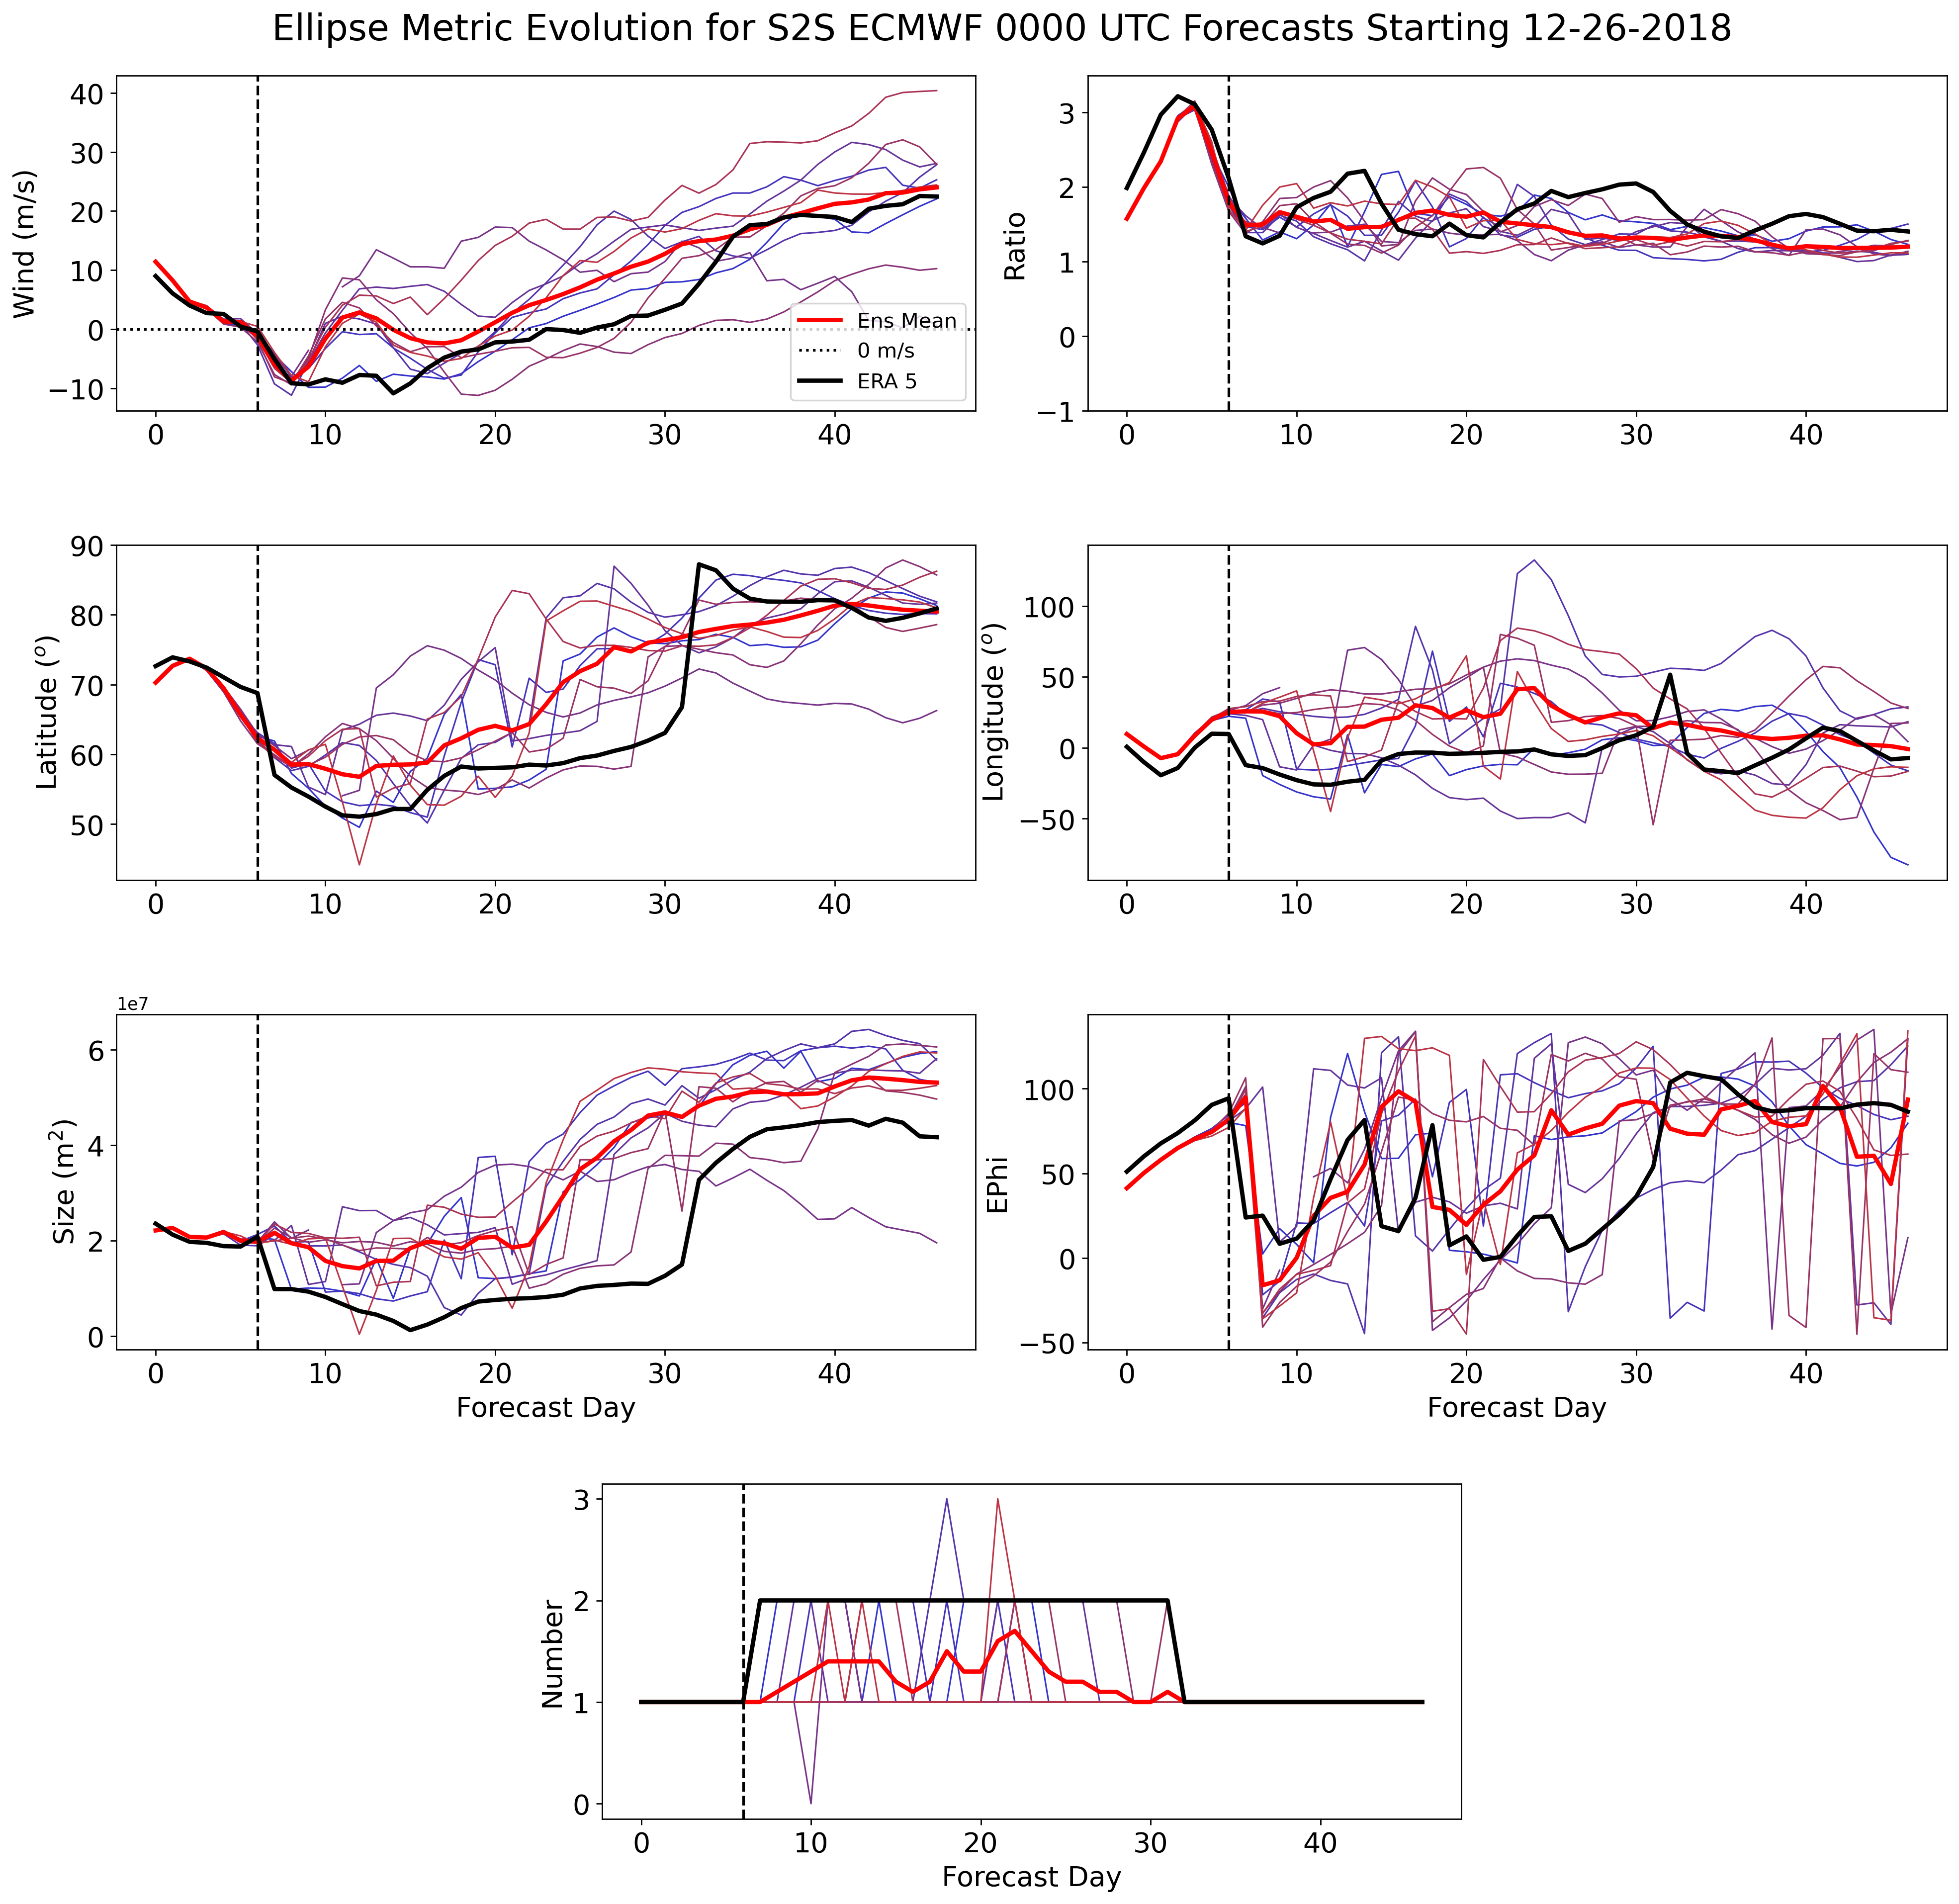

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

myLocator = mticker.MultipleLocator(5)

fig = plt.figure(figsize=(19,17), dpi=250)

# Use 4x4 grid for better control of spacing
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.3)

# Top 6 subplots in a 3x2 layout, each using two columns
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[2, 0:2])
ax6 = fig.add_subplot(gs[2, 2:4])

# Centered seventh subplot at the bottom, spanning columns 1 to 3
ax7 = fig.add_subplot(gs[3, 1:3])

fs = 16

for m in range(1, 12):
    if m == 11: 
        label = 'ERA 5'
        color = 'k'
        linewidth = 2.5
        ax1.axhline(y=0, color='k', linestyle=':', label="0 m/s")
    elif m == 10: 
        label = 'Ens Mean'
        color = 'r'
        linewidth = 2.5
    else: 
        label = None
        colorR = (m + 2) / 15.
        color = (colorR, .2, 1 - colorR)
        linewidth = .9

    ax1.plot(forecast_days, wind10[m, :], color=color, label=label, linewidth=linewidth)
    ax2.plot(forecast_days, rat10[m, :], color=color, label=label, linewidth=linewidth)
    ax3.plot(forecast_days, cenlat10[m, :], color=color, label=label, linewidth=linewidth)
    ax4.plot(forecast_days, cenlon10[m, :], color=color, label=label, linewidth=linewidth)
    ax5.plot(forecast_days, size10[m, :], color=color, label=label, linewidth=linewidth)
    ax6.plot(forecast_days, ep10[m, :], color=color, label=label, linewidth=linewidth)

    # Example data for subplot 7 — replace with actual
    ax7.plot(forecast_days, num10[m, :], color=color, label=label, linewidth=linewidth)

# Axis labels & formatting
ax1.set_ylabel('Wind (m/s)', fontsize=fs)
ax2.set_ylabel('Ratio', fontsize=fs)
ax2.set_ylim(-1, 3.5)
ax3.set_ylabel('Latitude ($^o$)', fontsize=fs)
ax4.set_ylabel('Longitude ($^o$)', fontsize=fs)
ax5.set_ylabel('Size (m$^2$)', fontsize=fs)
ax6.set_ylabel('EPhi', fontsize=fs)
ax5.set_xlabel('Forecast Day', fontsize=fs)
ax6.set_xlabel('Forecast Day', fontsize=fs)
ax7.set_ylabel('Number', fontsize=fs)
ax7.set_xlabel('Forecast Day', fontsize=fs)

# Common formatting
for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
    ax.axvline(x=forecast_days[6], color='k', linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=fs)

ax1.legend(loc='lower right', fontsize='large')

plt.suptitle("Ellipse Metric Evolution for S2S ECMWF 0000 UTC Forecasts Starting 12-26-2018", fontsize=21)
plt.subplots_adjust(top=0.95)
#plt.tight_layout()
#plt.show()
plt.savefig("S2SMetric_Series.png")